# LWE 문제와 Regev 공개키 암호
## Lattice-Based Cryptography I — Learning With Errors & Regev Encryption

---

이 노트북은 **격자 기반 양자내성암호(PQC, 양자컴퓨터가 나와도 안전하도록 설계된 암호)를 처음 배우는 사람**을 위한 강의 자료입니다.
격자 기반 암호의 뿌리인 **LWE(Learning With Errors, 오차 학습) 문제**를 쉬운 비유로 이해한 뒤,
이 문제를 그대로 이용해 만든 공개키 암호인 **Regev 암호**를 코드로 직접 만들어 보고,
**잡음을 얼마나 섞느냐에 따라 복호(암호 풀기)가 성공하거나 실패하는 줄타기**를 실험으로 확인합니다.

한 줄로 미리 말하면 이렇습니다. **"연립방정식에 아주 작은 오차를 섞으면, 답을 아는 사람은 풀 수 있지만
남들은 못 푸는 문제가 된다"** — 이것이 LWE이고, 격자 암호 전체의 출발점입니다.

> **안내**: 이 노트북은 통합본 `양자내성암호_입문자용_v3.ipynb`에서 해당 주제를 분리·정리한 강의 자료입니다.
> 실행 셀과 출력은 원본 그대로이며, 재실행하려면 **0장(Setup)의 공통 설정 셀을 가장 먼저 실행**해야 합니다.

### 학습 목표
1. LWE 문제가 무엇인지, 그리고 "일부러 섞은 작은 잡음"이 왜 문제를 어렵게 만드는지 비유로 이해한다.
2. Regev 공개키 암호가 열쇠 만들기(키 생성) → 잠그기(암호화) → 열기(복호)의 세 단계로 어떻게 돌아가는지 안다.
3. 무작위 비트를 암호화했다가 다시 풀어 보는 왕복 실험으로 정확성을 확인하고, 공개키·암호문의 크기를 재 본다.
4. 잡음을 점점 키우면 복호가 어떻게 무너지는지 그래프로 관찰한다.
5. Regev 암호의 한계와, 실제 표준인 ML-KEM(Kyber)으로 이어지는 개선 방향을 안다.

> **선행 지식**: 특별한 수학 지식 없이 읽을 수 있습니다. "나머지 연산(시계처럼 일정 숫자를 넘으면
> 처음으로 돌아가는 계산)"과 "연립방정식(미지수가 여러 개인 방정식 묶음)"이라는 말만 어렴풋이 알면 충분하며,
> 필요한 개념은 본문에서 그때그때 풀어 설명합니다.


## 0. 준비 (Setup)

실습 전체에서 공통으로 사용하는 도구를 준비합니다. `numpy`, `pandas`, `matplotlib` 를 사용합니다.

아래 셀은 통합본의 공통 설정(Harness, 실험 도구 모음) 셀입니다. 실험을 언제 돌려도 같은 결과가 나오게 하는
난수 시드(`RNG`), 그래프의 한글이 깨지지 않게 하는 폰트 설정, 해시 헬퍼(`H`, `shake`),
공개키·암호문의 크기를 바이트 단위로 재는 `nbytes`, 시간 측정 `timeit`,
측정값을 모아 두는 저장소 `METRICS` 를 정의합니다. 코드를 한 줄씩 이해할 필요는 없습니다 —
노트북을 재실행할 때 **이 셀을 반드시 가장 먼저 실행**한다는 것만 기억하세요.


In [1]:
import time, hashlib, secrets, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import gcd, log2, floor, pi, sqrt

RNG = np.random.default_rng(20260722)   # 재현성 시드
plt.rcParams['figure.dpi'] = 110

# --- 한글 폰트 자동 설정 (그래프의 한글이 □□□로 깨지지 않게) ---
import matplotlib.font_manager as fm

def set_korean_font():
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic',
                  'Noto Sans CJK KR', 'Noto Sans KR', 'NanumBarunGothic']
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams['font.family'] = name
            plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지
            return name
    # 못 찾으면 리눅스/Colab에서 나눔폰트 설치 시도
    try:
        import subprocess, sys
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'],
                       capture_output=True)
        for path in fm.findSystemFonts():
            if 'Nanum' in path:
                fm.fontManager.addfont(path)
        for name in candidates:
            if name in {f.name for f in fm.fontManager.ttflist}:
                plt.rcParams['font.family'] = name
                plt.rcParams['axes.unicode_minus'] = False
                return name
    except Exception:
        pass
    plt.rcParams['axes.unicode_minus'] = False
    print('⚠️ 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있어요. '
          'NanumGothic 등 한글 폰트를 설치한 뒤 다시 실행하세요.')
    return None

_font = set_korean_font()

# --- 해시 헬퍼 (해시 기반 서명·KEM 공유비밀에 사용) ---
def H(b: bytes) -> bytes:
    return hashlib.sha256(b).digest()
def shake(b: bytes, n: int) -> bytes:
    return hashlib.shake_128(b).digest(n)

# --- 크기 측정: 객체를 바이트로 직렬화해 대략적 전송량(byte)을 잰다 ---
def nbytes(obj) -> int:
    if isinstance(obj, (bytes, bytearray)):
        return len(obj)
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64).nbytes
    if isinstance(obj, (list, tuple)):
        return sum(nbytes(x) for x in obj)
    if isinstance(obj, str):
        return len(obj.encode())
    if isinstance(obj, int):
        return (obj.bit_length() + 7) // 8
    return sys.getsizeof(obj)

# --- 시간 측정 ---
def timeit(fn, *a, repeat=1, **k):
    t0 = time.perf_counter()
    for _ in range(repeat):
        out = fn(*a, **k)
    dt = (time.perf_counter() - t0) / repeat
    return out, dt

# --- 정량 지표 저장소 (Part IV 종합 비교에서 사용) ---
METRICS = {}
def log_metric(name, **kv):
    METRICS.setdefault(name, {}).update(kv)

print('Harness 준비 완료 · Python', sys.version.split()[0], '· NumPy', np.__version__,
      '· 한글 폰트:', _font)

Harness 준비 완료 · Python 3.13.14 · NumPy 2.4.6 · 한글 폰트: Malgun Gothic


## 1. LWE 문제 — 잡음 낀 연립방정식

**LWE(Learning With Errors, 오차 학습) 문제**는 격자 기반 PQC 전체의 뿌리가 되는 문제입니다.
이름은 어려워 보이지만, 핵심 아이디어는 놀랄 만큼 단순합니다.

**비유로 먼저 이해해 봅시다.** 선생님이 마음속으로 비밀 숫자 몇 개를 정해 두고,
그 숫자들로 만든 연립방정식 문제지를 나눠 준다고 상상하세요.
방정식이 정확하다면 학생들은 중학교에서 배운 소거법으로 비밀 숫자를 금방 알아냅니다.
그런데 선생님이 **각 방정식의 답에 ±1 정도의 아주 작은 오차를 일부러 섞어서** 나눠 주면 이야기가 달라집니다.
소거 과정에서 그 작은 오차들이 눈덩이처럼 불어나 계산이 엉망이 되고, 아무리 식이 많아도 비밀 숫자가 나오지 않습니다.
반면 "오차가 어떤 식으로 섞였는지"를 아는 사람(비밀키 주인)은 잡음을 걸러 내고 답을 복원할 수 있습니다.

이것을 기호로 쓰면 다음 한 줄이 됩니다. 이 노트북에서 꼭 기억할 수식은 이것 하나입니다.

$$\mathbf{b} = A\mathbf{s} + \mathbf{e} \pmod q$$

> **수식 풀이:**
> - $A$ 는 **공개된 문제지**(무작위로 만든 숫자표)입니다.
> - $\mathbf{s}$ 는 **나만 아는 답**(비밀키)입니다.
> - $\mathbf{e}$ 는 **일부러 섞은 작은 잡음**(오차)입니다.
> - $\mathbf{b}$ 는 "문제지에 답을 넣어 계산한 결과에 잡음을 살짝 얹은 것", 즉 **공개하는 정답지(잡음 포함)**입니다.
> - $\pmod q$ 는 모든 계산을 $q$ 로 나눈 나머지로 한다는 뜻입니다. 12를 넘으면 1로 돌아가는
>   시계 계산과 같은 방식이라 숫자가 한없이 커지지 않습니다.

문제지 $A$ 와 잡음 낀 정답지 $\mathbf{b}$ 를 공개해도, 남들이 비밀 $\mathbf{s}$ 를 알아내는 것은 어렵습니다.
잡음이 방정식을 살짝 흐트러뜨려서 보통의 풀이법(가우스 소거, 즉 소거법)이 통하지 않기 때문입니다.
더 중요한 사실은, **양자컴퓨터로도 이 문제를 빠르게 푸는 방법이 알려져 있지 않다**는 점입니다.
그래서 LWE가 "양자내성" 암호의 재료가 됩니다.


## 2. Regev 공개키 암호

LWE 문제를 그대로 이용하면 **1비트(0 또는 1 하나)를 안전하게 주고받는** 공개키 암호를 만들 수 있습니다.
공개키 암호란 "잠그는 열쇠(공개키)는 누구나 갖게 하고, 여는 열쇠(비밀키)는 나만 갖는" 방식의 암호입니다.
보내는 사람은 공개키만으로 잠그고, 받는 사람만 비밀키로 엽니다.

### 2-1. 구성

세 단계를 우체통에 비유하면 이렇습니다. 공개키는 "누구나 편지를 넣을 수 있는 우체통",
비밀키는 "우체통을 여는 나만의 열쇠"입니다.

- **키 생성(우체통 만들기)**: 비밀 숫자 묶음 $\mathbf{s}$(비밀키)를 뽑고, 무작위 문제지 $A$ 와
  $-1, 0, 1$ 중에서 뽑은 작은 잡음을 써서 1장의 식 그대로 잡음 낀 정답지 $\mathbf{b}$ 를 만듭니다.
  $(A, \mathbf{b})$ 묶음이 공개키가 됩니다.
- **암호화(편지 넣기)**: 보내는 사람은 공개키의 여러 줄(행) 가운데 **무작위로 몇 줄을 골라 더합니다.**
  어떤 줄을 골랐는지는 본인만 압니다. 그리고 보내려는 비트가 1이면 그 합에 **$q$ 의 절반쯤 되는 "큰 신호"를
  얹고**, 0이면 아무것도 얹지 않습니다. 이렇게 만든 두 값(고른 줄들의 합 $u$ 와, 신호가 실린 값 $v$)이 암호문입니다.
  비트는 작은 잡음들 사이에서 홀로 우뚝 솟은 큰 신호에 실려 전달되는 셈입니다.
- **복호(우체통 열기)**: 받는 사람은 비밀키 $\mathbf{s}$ 를 이용해 암호문에서 문제지 부분을 정확히 상쇄시킵니다.
  그러면 "작게 누적된 잡음 + (보낸 비트가 1이었다면) 큰 신호"만 남습니다. 남은 값이 $q$ 의 절반 근처면 1,
  0 근처면 0이라고 판정합니다. 누적된 잡음이 판정 여유(대략 $q$ 의 4분의 1)보다 작기만 하면
  이 판정은 틀리지 않습니다.

### 2-2. 밑바닥 구현과 검증

아래 셀은 Regev 암호의 키 생성·암호화·복호를 라이브러리 없이 그대로 구현합니다.
공부용 장난감 크기의 설정($n=8,\ m=32,\ q=97$ — 비밀 숫자 8개, 방정식 32줄, 나머지 연산의 기준 97)에서
무작위 비트를 2000회 암호화했다가 다시 풀어 보는 왕복 실험으로 정확성을 검증하고,
공개키와 암호문(1비트당)의 크기도 함께 측정합니다.


In [8]:
# ③ 밑바닥 구현 — Regev 공개키 암호
def regev_keygen(n, m, q, rng):
    s = rng.integers(0, q, size=n)                 # 비밀키 s
    Amat = rng.integers(0, q, size=(m, n))         # 공개 행렬 A
    e = rng.integers(-1, 2, size=m)                # 작은 오차 e in {-1,0,1}
    b = (Amat @ s + e) % q                         # b = A s + e
    return (Amat, b), s

def regev_enc(pk, bit, q, rng):
    Amat, b = pk
    m = Amat.shape[0]
    r = rng.integers(0, 2, size=m)                 # 무작위 부분집합 선택
    u = (r @ Amat) % q                             # u = r^T A
    v = (int(r @ b) + bit * (q // 2)) % q          # v = r^T b + bit*floor(q/2)
    return u, v

def regev_dec(sk, ct, q):
    u, v = ct
    d = (v - int(u @ sk)) % q                       # v - u^T s ~ bit*floor(q/2) + 작은오차
    return 1 if abs(d - q // 2) < q // 4 else 0     # q/2 근처면 1, 0 근처면 0

# ④ 검증 — 2000회 무작위 비트 왕복
n, m, q = 8, 32, 97
pk, sk = regev_keygen(n, m, q, RNG)
errs = 0; T = 2000
for _ in range(T):
    bit = int(RNG.integers(0, 2))
    ct = regev_enc(pk, bit, q, RNG)
    if regev_dec(sk, ct, q) != bit:
        errs += 1
print(f'n={n}, m={m}, q={q} → 복호 오류 {errs}/{T} = {errs/T:.4f}')
print(f'공개키 크기 ~{nbytes(pk)} B, 암호문 크기 ~{nbytes(ct)} B (1비트당)')

n=8, m=32, q=97 → 복호 오류 0/2000 = 0.0000
공개키 크기 ~2304 B, 암호문 크기 ~65 B (1비트당)


### 2-3. 결과 해석

- 복호 오류는 **0/2000 (0.0000)** 입니다. 잡음을 $-1, 0, 1$ 로 작게 유지하면
  복호 때 남는 누적 잡음이 판정 여유($q$ 의 4분의 1)를 넘지 않아, 2000번 모두 정확히 풀렸습니다.
- 크기는 공개키 약 **2304 B**, 암호문 약 **65 B** 로 측정되었습니다. 단, 이 암호문 크기는 **1비트당** 크기입니다 —
  0 또는 1 **하나**를 보내는 데 65바이트짜리 소포가 통째로 필요하다는 뜻입니다.
  편지 한 글자를 보내려고 택배 상자 하나를 쓰는 셈이지요. 이 비효율이 Regev 암호의 본질적 한계이며,
  3-2절에서 다시 다룹니다.


## 3. 오차 크기와 복호 실패의 트레이드오프

이제 LWE 설계의 핵심 긴장 관계를 실험으로 확인합니다. 지금까지는 잡음을 $-1, 0, 1$ 로 고정했지만,
잡음의 범위를 $-\eta$ 부터 $\eta$ 까지로 넓힐 수 있다고 해 봅시다($\eta$, "에타"는 잡음의 최대 크기를 뜻하는 손잡이입니다).

- 잡음이 **클수록** 비밀이 더 잘 가려져 **공격자가 뚫기 어려워지지만**(안전성 상승),
- 잡음이 **너무 크면** 정작 주인이 복호할 때도 누적 잡음이 큰 신호를 잡아먹어 **복호가 무너집니다.**

즉 잡음은 "많이 섞을수록 안전하지만, 너무 많이 섞으면 나도 못 여는" 양날의 칼입니다.

아래 셀은 $\eta$ 를 1부터 12까지 하나씩 키워 가며 매번 키를 새로 만들고, 800회 왕복 실험으로
복호 오류율(풀기에 실패한 비율)을 측정하여 그래프로 그립니다.


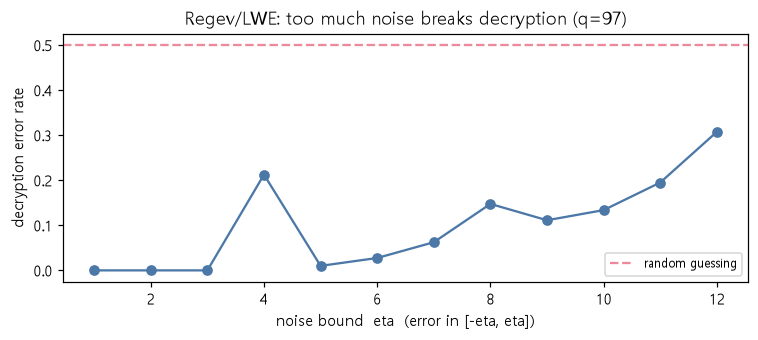

In [9]:
def regev_keygen_eta(n, m, q, eta, rng):
    s = rng.integers(0, q, size=n)
    Amat = rng.integers(0, q, size=(m, n))
    e = rng.integers(-eta, eta + 1, size=m)
    b = (Amat @ s + e) % q
    return (Amat, b), s

etas = list(range(1, 13))
rates = []
for eta in etas:
    pk_e, sk_e = regev_keygen_eta(n, m, q, eta, RNG)
    bad = 0; TT = 800
    for _ in range(TT):
        bit = int(RNG.integers(0, 2))
        bad += regev_dec(sk_e, regev_enc(pk_e, bit, q, RNG), q) != bit
    rates.append(bad / TT)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(etas, rates, 'o-', color='#4C78A8')
ax.set_xlabel('noise bound  eta  (error in [-eta, eta])'); ax.set_ylabel('decryption error rate')
ax.set_title(f'Regev/LWE: too much noise breaks decryption (q={q})')
ax.axhline(0.5, color='crimson', ls='--', alpha=.5, label='random guessing')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
log_metric('Regev/LWE', pk_bytes=nbytes(pk), ct_bytes=nbytes(ct), err=errs/T)

### 3-1. 그래프 해석

가로축은 일부러 섞는 잡음의 최대 크기 $\eta$, 세로축은 복호에 실패한 비율입니다.
빨간 가로 점선(0.5)은 "동전 던지기로 찍는 것과 같은" 수준, 즉 복호가 완전히 무너진 상태를 뜻합니다.

왼쪽(잡음이 작은 구간)에서는 오류율이 0 근처이지만, 오른쪽으로 갈수록 전반적으로 올라가 0.5에 다가갑니다.
선이 들쭉날쭉한 것은 버그가 아닙니다 — 이 실험은 $q=97$ 이라는 아주 작은 공부용 설정을 쓰고
$\eta$ 마다 키를 새로 뽑기 때문에 생기는 통계적 요동(우연에 의한 출렁임)이며,
큰 흐름(오른쪽으로 갈수록 상승)을 읽으면 됩니다.

> **핵심**: 잡음은 비밀을 가려 주는 안개와 같습니다. 안개가 옅으면(잡음이 작으면) 공격자가 꿰뚫어 보고,
> 너무 짙으면 정작 주인도 길을 잃습니다(복호 실패). 실제 표준 암호의 설정값은 이
> **"안전성 vs 정확성"** 의 줄타기를 정밀하게 맞춘 결과입니다.


### 3-2. 실무 적용성

- **측정에서 확인한 것**: 잡음이 적당하면 복호 오류가 0%이지만, 잡음을 키우면 복호가 무너집니다 →
  설정값(파라미터)은 **"안전성(큰 잡음) vs 정확성(작은 잡음)"의 절충**입니다.
- **한계**: Regev 암호는 0/1 하나를 보낼 때마다 큰 소포(벡터 하나)가 필요해서 **매우 비효율적**입니다
  (암호문이 큽니다). 원리를 배우는 교육용으로는 완벽하지만 실전에는 쓸 수 없습니다.
- **개선 방향**: 숫자 묶음 대신 **다항식**(여러 숫자를 한 덩어리로 묶어 한꺼번에 계산하는 수식 형태)을 쓰고,
  여러 비트를 한 번에 담으면 크기와 속도가 급격히 좋아집니다 → 이것이 바로 다음 주제인
  **ML-KEM(Kyber, 격자 기반의 국제 표준 키 교환 암호)** 입니다.
- 실무에서 격자 암호의 설정값을 임의로 줄이거나 바꾸면 안 되는 이유가 바로 이 줄타기에 있습니다 —
  **표준이 정한 파라미터를 그대로 사용해야 합니다.**

> "잡음 낀 연립방정식(LWE)"만으로도 공개키 암호가 만들어지지만,
> 실용화하려면 다항식 구조(다음 주제)가 필요합니다.


## 연습문제

직접 코드를 고쳐 보면서 감을 잡아 보세요.

1. **판정 여유와 나머지 기준 $q$**: 2장의 왕복 실험에서 `q` 를 97에서 31로 줄여 다시 실행해 보세요.
   $q$ 가 작아지면 "0 근처인지 절반 근처인지"를 가르는 판정 여유($q$ 의 4분의 1)도 좁아집니다.
   복호 오류가 발생하기 시작하나요?

2. **방정식 개수 $m$ 의 효과**: `m` 을 32에서 128로 키우면, 복호 때 남는 누적 잡음의 크기,
   복호 오류율, 그리고 `nbytes(pk)` 로 측정한 공개키 크기가 각각 어떻게 변하나요?

3. **요동 줄이기**: 3장의 `TT = 800` 을 5000으로 키우고, $\eta$ 마다 키를 여러 번 새로 뽑아
   오류율을 평균 내도록 수정해 보세요. 그래프의 들쭉날쭉함이 줄어드나요?

4. **잡음 제거 실험**: `regev_keygen` 에서 잡음을 `e = np.zeros(m, dtype=int)` 로 바꾸면(잡음 없음)
   복호는 어떻게 되나요? 이때 공개키 $(A, \mathbf{b})$ 만 보고도 비밀키를 보통의 소거법(가우스 소거)으로
   복원할 수 있게 되는 이유, 즉 잡음이 없으면 암호가 무너지는 이유를 설명해 보세요.


## 요약

- LWE 문제는 "잡음 낀 연립방정식"입니다. 공개된 문제지 $A$ 와 잡음 낀 정답지 $\mathbf{b}$ 만 보고
  비밀 $\mathbf{s}$ 를 찾는 문제로, 일부러 섞은 작은 잡음 덕분에 보통의 소거법으로는 풀리지 않으며
  **양자컴퓨터로도 빠른 풀이가 알려져 있지 않습니다.**
- Regev 암호는 LWE를 그대로 이용한 공개키 암호입니다. 보낼 비트를 $q$ 의 절반쯤 되는 큰 신호에 실어 보내고,
  복호 때 남는 누적 잡음이 판정 여유($q$ 의 4분의 1)보다 작으면 정확히 풀립니다.
- 장난감 설정 $n=8,\ m=32,\ q=97$ 의 2000회 왕복 실험에서 복호 오류 0회를 확인했습니다
  (공개키 약 2304 B, 암호문 1비트당 약 65 B).
- 잡음의 최대 크기 $\eta$ 를 키우면 안전성은 올라가지만 복호 오류율이 상승해 0.5(동전 던지기 수준)에
  다가갑니다 — 설정값 설계는 **안전성과 정확성의 절충**입니다.
- Regev는 1비트당 큰 소포 하나가 필요해 비효율적이며, 이를 다항식 구조로 실용화한 것이
  표준 **ML-KEM(Kyber)** 입니다.

> 다음 노트북에서는 이 구조를 다항식 위로 옮겨 실용화한 ML-KEM(Kyber)을 다룹니다.
